U(V),I(mA)
-16.0,-4.25e-3
-15.0,-4.12e-3
-14.0,-3.61e-3
-13.0,-3.42e-3
-12.0,-3.17e-3
-11.0,-3.02e-3
-10.0,-2.91e-3
-8.99,-2.57e-3
-7.99,-2.51e-3
-6.99,-2.48e-3
-5.99,-2.42e-3
-4.99,-2.15e-3
-3.99,-4.27e-3
-2.99,-3.52e-3
-1.99,-2.42e-3
-1.00,-1.37e-2
0,0
0.498,4.59e-3
0.995,4.20e-5
1.43,2.69
1.80,8.27
2.18,15.2
2.71,14.3
3.26,11.68
3.84,7.99
4.39,5.52
4.96,1.30
5.46,1.22
5.96,1.36
6.46,1.49
6.96,1.62
7.45,1.75
7.95,1.88
8.94,2.13
9.94,2.39
10.9,2.65
11.9,2.91
12.9,3.17
13.9,3.43
14.9,3.69
15.9,3.95


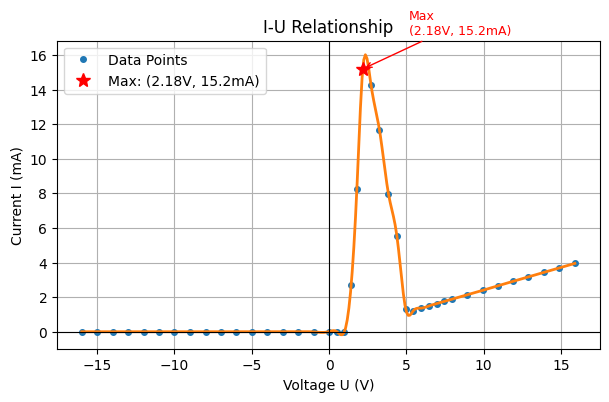

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np
from scipy.interpolate import interp1d

# Prepare data (original units: U in V, I in mA)
data = '''U(V),I(mA)
-16.0,-4.25e-3
-15.0,-4.12e-3
-14.0,-3.61e-3
-13.0,-3.42e-3
-12.0,-3.17e-3
-11.0,-3.02e-3
-10.0,-2.91e-3
-8.99,-2.57e-3
-7.99,-2.51e-3
-6.99,-2.48e-3
-5.99,-2.42e-3
-4.99,-2.15e-3
-3.99,-4.27e-3
-2.99,-3.52e-3
-1.99,-2.42e-3
-1.00,-1.37e-2
0,0
0.498,4.59e-3
0.995,4.20e-5
1.43,2.69
1.80,8.27
2.18,15.2
2.71,14.3
3.26,11.68
3.84,7.99
4.39,5.52
4.96,1.30
5.46,1.22
5.96,1.36
6.46,1.49
6.96,1.62
7.45,1.75
7.95,1.88
8.94,2.13
9.94,2.39
10.9,2.65
11.9,2.91
12.9,3.17
13.9,3.43
14.9,3.69
15.9,3.95'''
df = pd.read_csv(StringIO(data))

# Sort data by voltage for smooth interpolation
df_sorted = df.sort_values('U(V)')

# Create smooth curve using interpolation
U_smooth = np.linspace(df_sorted['U(V)'].min(), df_sorted['U(V)'].max(), 300)
f = interp1d(df_sorted['U(V)'], df_sorted['I(mA)'], kind='cubic')
I_smooth = f(U_smooth)

plt.figure(figsize=(7,4))
# Plot original data points
plt.plot(df['U(V)'], df['I(mA)'], 'o', markersize=4, label='Data Points')
# Plot smooth curve
plt.plot(U_smooth, I_smooth, '-', linewidth=2, label='')
plt.xlabel('Voltage U (V)')
plt.ylabel('Current I (mA)')
plt.title('I-U Relationship')
plt.grid(True)
plt.legend()
# Add axough origin
plt.axhline(y=0, color='k', linewidth=0.8)
plt.axvline(x=0, color='k', linewidth=0.8)
plt.savefig('iu_relationship3.png')
plt.show()3